In [ ]:
import requests
import pandas as pd

url = "https://api.openf1.org/v1/car_data"

params = {
    "session_key": 'latest',
    "driver_number": 1,
}

data = requests.get(url, params=params).json()

df = pd.DataFrame(data)

df.head()

                               date  session_key  speed   drs  rpm  brake  \
0  2026-09-12T15:04:14.568000+00:00        11369      0  None    0    104   
1  2026-09-12T15:04:14.768000+00:00        11369      0  None    0    104   
2  2026-09-12T15:04:14.968000+00:00        11369      0  None    0    104   
3  2026-09-13T12:08:42.813000+00:00        11369      0  None    0      0   
4  2026-09-13T12:08:42.973000+00:00        11369      0  None    0      0   

   driver_number  throttle  meeting_key  n_gear  
0              1       104         1294       0  
1              1       104         1294       0  
2              1       104         1294       0  
3              1         0         1294       0  
4              1         0         1294       0  


In [5]:
df.head()

,date,session_key,speed,drs,rpm,brake,driver_number,throttle,meeting_key,n_gear
0,2026-09-12T15:04:14.568000+00:00,11369,0,None,0,104,1,104,1294,0
1,2026-09-12T15:04:14.768000+00:00,11369,0,None,0,104,1,104,1294,0
2,2026-09-12T15:04:14.968000+00:00,11369,0,None,0,104,1,104,1294,0
3,2026-09-13T12:08:42.813000+00:00,11369,0,None,0,0,1,0,1294,0
4,2026-09-13T12:08:42.973000+00:00,11369,0,None,0,0,1,0,1294,0


In [7]:
df[df['driver_number']==1]['speed']

0        0
1        0
2        0
3        0
4        0
        ..
35551    0
35552    0
35553    0
35554    0
35555    0
Name: speed, Length: 35556, dtype: int64

In [10]:
1/3.7

0.27027027027027023

<Axes: ylabel='speed'>

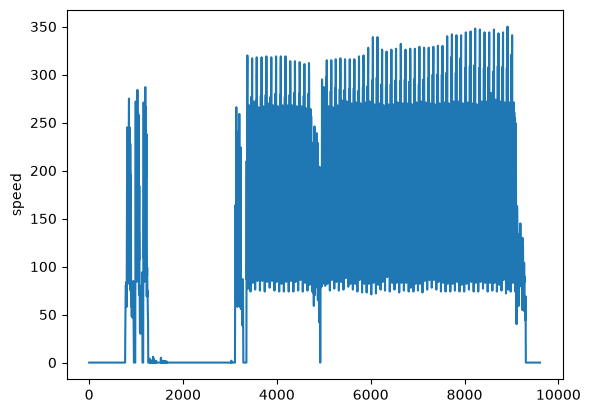

In [12]:
import seaborn as sns

x=[1/3.7 * (i+1) for i in range(len(df[df['driver_number']==1]['speed']))]

sns.lineplot(x=x,y=df[df['driver_number']==1]['speed'])

In [6]:
import requests
import pandas as pd
from urllib.parse import quote


YEAR = 2026
EVENT = "Spanish Grand Prix"   # Madrid, 13 Sep 2026
SESSION = "Race"

BASE = f"https://raw.githubusercontent.com/TracingInsights/{YEAR}/main"


def load_json(path: str):
    url = f"{BASE}/{quote(path, safe='/')}"

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    return response.json()


# ============================================================
# 1. УЧАСТНИКИ
# ============================================================

drivers_raw = load_json(
    f"{EVENT}/{SESSION}/drivers.json"
)

drivers = pd.DataFrame(drivers_raw["drivers"])

print("DRIVERS:")
print(drivers)

DRIVERS:
   driver             team  dn         fn          ln      tc  \
0     NOR          McLaren   1      Lando      Norris  F47600   
1     GAS           Alpine  10     Pierre       Gasly  00A1E8   
2     PER         Cadillac  11     Sergio       Perez  909090   
3     ANT         Mercedes  12       Kimi   Antonelli  00D7B6   
4     ALO     Aston Martin  14   Fernando      Alonso  229971   
5     LEC          Ferrari  16    Charles     Leclerc  ED1131   
6     STR     Aston Martin  18      Lance      Stroll  229971   
7     TSU     Racing Bulls  22       Yuki     Tsunoda  6C98FF   
8     ALB         Williams  23  Alexander       Albon  1868DB   
9     HUL             Audi  27       Nico  Hulkenberg  F50537   
10    VER  Red Bull Racing   3        Max  Verstappen  4781D7   
11    LAW  Red Bull Racing  30       Liam      Lawson  4781D7   
12    OCO     Haas F1 Team  31    Esteban        Ocon  9C9FA2   
13    LIN     Racing Bulls  41      Arvid    Lindblad  6C98FF   
14    COL       